# GR-Prediction - Local Eval (Discretized S6)

Evaluates the **CREPE-style discretized S6** gain-reduction model locally. It mirrors the discretized LSTM eval notebook, but checkpoint reconstruction uses the shared `src.gr_s6` model and Lightning system.

Features:

- List S6 training runs and checkpoints.
- Plot BCE loss and dB MAE curves.
- Predict GR on dry/wet pairs and compare to RMS-derived ground truth.
- Visualize the full 151-bin probability distribution as a heatmap.
- Optionally compute validation-set reconstructed-audio metrics.

Requirements: run `uv sync` at repo root first.

In [1]:
# 0. Imports, defaults, and run discovery

import gc
import glob
import json
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn.functional as F
import torchaudio

warnings.filterwarnings("ignore", category=UserWarning)

from src.dsp_torch import GR_DB_MAX, GR_DB_MIN, RMS_WINDOW, gain_reduction_db
from src.gr_s6 import (
    GR_NUM_BINS,
    DiscretizedGRPredictionSystem,
    build_frame_rate_s6_from_hparams,
    gr_bin_centers,
)

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"

# Set SELECTED_RUN_NAME in the run-selection cell after available runs are listed.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


from eval_helpers import _checkpoint_sort_key, latest_best_checkpoint, list_runs


print(f"torch {torch.__version__} | device: {DEVICE}")
print(f"Runs dir: {RUNS_DIR}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0 | device: cpu
Runs dir: /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs


In [2]:
# 1. List available S6 runs

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs found in {RUNS_DIR}"

available_models_df = runs_df[runs_df["type"] == "frame_rate_s6_discretized"].copy()
assert not available_models_df.empty, "No S6 runs found."

display_cols = ["run", "type", "setting", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available S6 runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Found 4 S6 run(s)
Selected run   : s6_gr_20260525_181724_s6_v1_discretized_fixed_v3
Model type     : frame_rate_s6_discretized
Eval checkpoint: best-166-17702.ckpt
Best val loss  : 0.074727


,run,type,setting,epoch,best_val,n_ckpts,eval_ckpt,modified
5,tcn_gr_20260418_115407,?,None,96.0,0.002399,23,best-096-8439.ckpt,2026-05-25 10:00:13.102122784
6,tcn_gr_20260418_125431_rf1_5s_n14_d2,?,None,NaN,NaN,25,best-097-4312.ckpt,2026-05-25 10:00:13.199025393
7,tcn_gr_20260418_135645_rf2_7s_n10_d3,?,None,105.0,0.028991,25,best-105-4664.ckpt,2026-05-25 10:00:13.297005415
8,tcn_gr_20260418_143050_no_batch_norm,?,None,130.0,0.034938,30,best-021-968.ckpt,2026-05-25 10:00:13.436656237
9,tcn_gr_20260426_093002_with_recommendations,?,threshold_-4_attack_1_release_0.4_ratio_10,230.0,0.023034,52,best-228-9847.ckpt,2026-05-25 10:00:13.506071568
10,tcn_gr_20260427_094122_with_recommendations_h100,?,threshold_-4_attack_1_release_0.4_ratio_10,427.0,0.024866,89,best-426-18361.ckpt,2026-05-25 10:00:13.653799295
11,gcn_gr_20260427_102709_gcn_warmup_mask_randomc...,gcn,threshold_-4_attack_1_release_0.4_ratio_10,67.0,0.024966,17,best-067-7004.ckpt,2026-05-25 10:00:13.742258072
12,gcn_gr_20260427_104716_gcn_split_fix,gcn,threshold_-4_attack_1_release_0.4_ratio_10,63.0,0.041425,39,best-060-6466.ckpt,2026-05-25 10:00:13.860494375
13,lstm_gr_20260507_172935_lstm_v1,frame_rate_lstm,threshold_-4_attack_1_release_0.4_ratio_10,143.0,0.001403,32,best-056-3021.ckpt,2026-05-25 10:00:13.944130182
14,lstm_gr_20260507_190047_lstm_v2,frame_rate_lstm,threshold_-4_attack_1_release_0.4_ratio_10,75.0,0.593050,19,best-028-1537.ckpt,2026-05-25 10:00:14.094592810


In [ ]:
# 2. Select run and checkpoint

SELECTED_RUN_NAME = "s6_gr_20260525_181724_s6_v1_discretized_fixed_v3"

matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
assert len(matches) == 1, f"Run not found in available S6 runs: {SELECTED_RUN_NAME}"
selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = str(selected_run["path"])
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")

print(f"Selected run   : {RUN_NAME}")
print(f"Model type     : {selected_run['type']}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

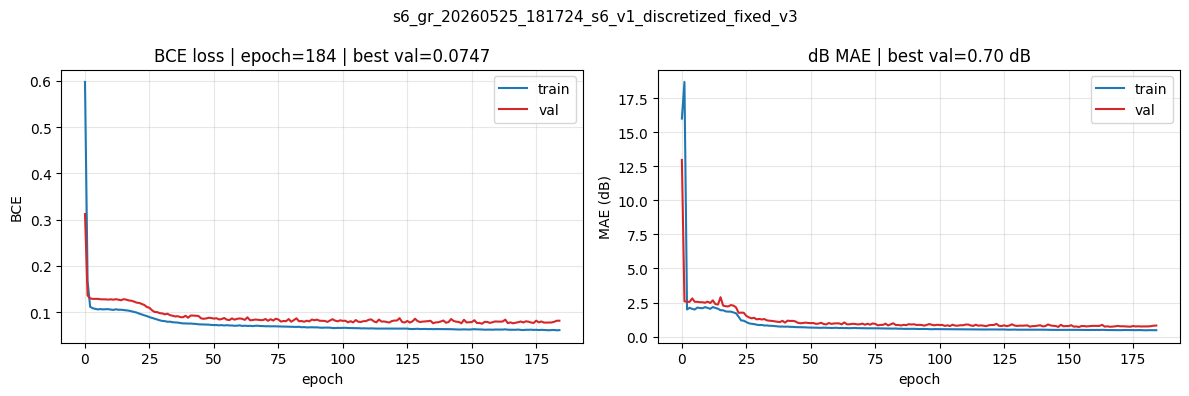

In [3]:
# 2. Plot training curves


def plot_loss_curves(run_dir=None, ymin=None):
    run_dir = run_dir or RUN_DIR
    csv_path = os.path.join(run_dir, "csv", "metrics.csv")
    if not os.path.isfile(csv_path):
        print(f"No metrics.csv yet at {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    has_mae = "mae_db/train" in df.columns or "mae_db/val" in df.columns
    ncols = 2 if has_mae else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4), squeeze=False)
    axes = axes[0]

    ax = axes[0]
    for split, color in [("train", "#1f77b4"), ("val", "#d62728")]:
        col = f"loss/{split}"
        if col in df.columns:
            rows = df.dropna(subset=[col])[["epoch", col]]
            ax.plot(rows["epoch"], rows[col], label=split, lw=1.5, color=color)
    ax.set_xlabel("epoch")
    ax.set_ylabel("BCE")
    ax.grid(alpha=0.3)
    ax.legend()
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    val = df.dropna(subset=["loss/val"]) if "loss/val" in df.columns else pd.DataFrame()
    best_val = float(val["loss/val"].min()) if len(val) else float("nan")
    last_epoch = int(df["epoch"].dropna().max()) if "epoch" in df.columns and df["epoch"].notna().any() else -1
    ax.set_title(f"BCE loss | epoch={last_epoch} | best val={best_val:.4f}")

    if has_mae:
        ax2 = axes[1]
        for split, color in [("train", "#1f77b4"), ("val", "#d62728")]:
            col = f"mae_db/{split}"
            if col in df.columns:
                rows = df.dropna(subset=[col])[["epoch", col]]
                ax2.plot(rows["epoch"], rows[col], label=split, lw=1.5, color=color)
        ax2.set_xlabel("epoch")
        ax2.set_ylabel("MAE (dB)")
        ax2.grid(alpha=0.3)
        ax2.legend()
        val_mae = df.dropna(subset=["mae_db/val"]) if "mae_db/val" in df.columns else pd.DataFrame()
        best_mae = float(val_mae["mae_db/val"].min()) if len(val_mae) else float("nan")
        ax2.set_title(f"dB MAE | best val={best_mae:.2f} dB")

    fig.suptitle(os.path.basename(run_dir), fontsize=11)
    plt.tight_layout()
    plt.show()
    return df


from eval_helpers import plot_loss_curves

_ = plot_loss_curves(RUN_DIR)

In [4]:
# 3. Checkpoint loading


from eval_helpers import _find_hparams_json


def load_system_from_ckpt(ckpt_path, hparams_path=None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), (
        f"hparams.json not found near {ckpt_path}"
    )

    with open(hparams_path) as f:
        hp = json.load(f)

    model = build_frame_rate_s6_from_hparams(hp)
    loss_hp = hp.get("loss", {})
    system = DiscretizedGRPredictionSystem.load_from_checkpoint(
        ckpt_path,
        model=model,
        map_location=DEVICE,
        lr=hp.get("lr", 1e-3),
        sigma_bins=loss_hp.get("sigma_bins", 2.0),
        warmup_frames=loss_hp.get("warmup_frames", 4),
        lr_patience=hp.get("lr_plateau_patience", 20),
        min_lr=hp.get("min_lr", 1e-6),
        local_avg_window=loss_hp.get("local_avg_window", 5),
    )
    system.to(DEVICE)
    system.eval()
    return system, hp


system, hp = load_system_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
n_params = sum(p.numel() for p in system.model.parameters())
n_trainable = sum(p.numel() for p in system.model.parameters() if p.requires_grad)
print("Loaded S6 checkpoint")
print(f"Model type : {hp.get('model_type')}")
print(f"Setting    : {hp.get('setting')}")
print(f"Params     : {n_params:,} total | {n_trainable:,} trainable")
print(f"S6 config  : {hp.get('s6', {})}")

Loaded S6 checkpoint
Model type : frame_rate_s6_discretized
Setting    : threshold_-4_attack_1_release_0.4_ratio_10
Params     : 66,135 total | 66,135 trainable
S6 config  : {'hop_size': 256, 'encoder_channels': 32, 'model_dim': 64, 'state_dim': 32, 'num_s6_layers': 2, 'dropout': 0.0, 'stateful': False, 'fixed_out_projection': True, 'frame_rate_hz': 172.265625, 'seq_len_frames': 1722, 'num_params': 66135, 'num_trainable_params': 57815}


In [5]:
# 4. Prediction and visualization helpers


def same_setting_pairs(data_root, setting):
    dry_dir = os.path.join(data_root, "processed_normalized")
    wet_dir = os.path.join(data_root, "processed_ground_truth", setting)
    assert os.path.isdir(dry_dir), f"Missing: {dry_dir}"
    assert os.path.isdir(wet_dir), f"Missing: {wet_dir}"

    dry_lookup = {
        os.path.basename(path).replace("_UnmasteredWAV.wav", ""): path
        for path in sorted(glob.glob(os.path.join(dry_dir, "*_UnmasteredWAV.wav")))
    }
    pairs = []
    for wet_path in sorted(glob.glob(os.path.join(wet_dir, "*-exported.wav"))):
        song = os.path.basename(wet_path).replace("-exported.wav", "")
        if song in dry_lookup:
            pairs.append((dry_lookup[song], wet_path))
    assert pairs, f"No dry/wet pairs for {setting}"
    return pairs


from eval_helpers import _read_dry_wet_segment, same_setting_pairs


@torch.no_grad()
def predict_gr_curves(
    ckpt_path,
    dry_wav_path,
    wet_wav_path,
    start_sec=0.0,
    duration_sec=6.0,
    hparams_path=None,
    pre_roll_sec=None,
):
    system, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"])
    rms_win = int(hp.get("rms_window", RMS_WINDOW))
    hop = int(hp.get("s6", {}).get("hop_size", 256))
    rf_samples = hop * 4

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    pre_roll = rf_samples if pre_roll_sec is None else int(round(pre_roll_sec * sr))
    context_start = max(0, start - pre_roll)
    context_offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_wav_path, wet_wav_path, context_start, stop, sr)
    gr_target_db = gain_reduction_db(
        dry.unsqueeze(0), wet.unsqueeze(0), rms_win
    ).squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)

    if hasattr(system.model, "reset_states"):
        system.model.reset_states()
    logits = system(dry.unsqueeze(0).to(DEVICE))
    gr_pred_db = system.model.to_db(logits, samples=dry.shape[-1]).squeeze(0).cpu()

    n = min(
        stop - start,
        dry.shape[-1] - context_offset,
        gr_target_db.shape[-1] - context_offset,
        gr_pred_db.shape[-1] - context_offset,
    )
    assert n > 0
    window = slice(context_offset, context_offset + n)

    gr_true = gr_target_db[..., window].squeeze().cpu().numpy()
    gr_pred = gr_pred_db[..., window].squeeze().cpu().numpy()
    dry_wave = dry[..., window].squeeze().cpu().numpy()

    probs_full = torch.sigmoid(logits).squeeze(0).cpu()
    frame_start = context_offset // hop
    frame_end = min((context_offset + n) // hop + 1, probs_full.shape[1])
    bin_probs = probs_full[:, frame_start:frame_end].numpy()

    err = gr_pred - gr_true
    song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")

    return {
        "song": song,
        "setting": hp["setting"],
        "model_type": hp.get("model_type", "frame_rate_s6_discretized"),
        "ckpt": ckpt_path,
        "sample_rate": sr,
        "start_sec": start_sec,
        "duration_sec": n / sr,
        "pre_roll_sec": context_offset / sr,
        "time": np.arange(n) / sr,
        "dry": dry_wave,
        "gr_true": gr_true,
        "gr_pred": gr_pred,
        "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "bin_probs": bin_probs,
        "hop_size": hop,
        "hparams": hp,
    }


@torch.no_grad()
def visualize_prediction(
    ckpt_path,
    dry_wav_path=None,
    wet_wav_path=None,
    start_sec=0.0,
    duration_sec=6.0,
    hparams_path=None,
    pre_roll_sec=None,
    title=None,
    show_heatmap=True,
):
    _, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    setting = hp["setting"]
    pairs = same_setting_pairs(DATA_ROOT, setting)

    if dry_wav_path is None:
        dry_wav_path, wet_wav_path = pairs[0]
    elif wet_wav_path is None:
        song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
        wet_wav_path = os.path.join(
            DATA_ROOT,
            "processed_ground_truth",
            setting,
            f"{song}-exported.wav",
        )

    curves = predict_gr_curves(
        ckpt_path=ckpt_path,
        dry_wav_path=dry_wav_path,
        wet_wav_path=wet_wav_path,
        start_sec=start_sec,
        duration_sec=duration_sec,
        hparams_path=hparams_path,
        pre_roll_sec=pre_roll_sec,
    )

    time = curves["time"]
    n_rows = 4 if show_heatmap else 3
    ratios = [1, 2, 1, 2] if show_heatmap else [1, 2, 1]
    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(11, 3 * n_rows - 2),
        sharex=True,
        gridspec_kw={"height_ratios": ratios},
    )

    axes[0].plot(time, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry")
    axes[0].set_ylim(-1.05, 1.05)
    axes[0].grid(alpha=0.3)

    axes[1].plot(time, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(time, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("GR (dB)")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    axes[2].plot(time, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)")
    axes[2].grid(alpha=0.3)

    if show_heatmap:
        probs = curves["bin_probs"]
        extent = [time[0], time[-1], GR_DB_MIN, GR_DB_MAX]
        im = axes[3].imshow(
            probs,
            aspect="auto",
            origin="lower",
            extent=extent,
            cmap="magma",
            vmin=0,
            vmax=1,
            interpolation="bilinear",
        )
        axes[3].plot(time, curves["gr_true"], color="cyan", lw=0.8, alpha=0.8, label="target")
        axes[3].plot(time, curves["gr_pred"], color="lime", lw=0.8, alpha=0.8, label="predicted")
        axes[3].set_ylabel("GR (dB)")
        axes[3].legend(loc="lower right", fontsize=8)
        fig.colorbar(im, ax=axes[3], label="P(bin)", shrink=0.8)

    axes[-1].set_xlabel("time (s)")
    ttl = title or (
        f"{curves['song']} | {curves['model_type']} | {curves['setting']}\n"
        f"ckpt={os.path.basename(ckpt_path)} "
        f"pre-roll={curves['pre_roll_sec']:.2f}s "
        f"MAE={curves['mae_db']:.2f} dB RMSE={curves['rmse_db']:.2f} dB"
    )
    fig.suptitle(ttl, fontsize=10)
    plt.tight_layout()
    plt.show()
    return curves


def compare_same_setting_curves(
    ckpt_path,
    start_sec=30.0,
    duration_sec=5.0,
    max_pairs=2,
    start_pair=0,
    hparams_path=None,
    show_heatmap=True,
):
    _, hp = load_system_from_ckpt(ckpt_path, hparams_path)
    pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
    selected = pairs[start_pair:max_pairs + start_pair]
    print(f"Comparing {len(selected)} of {len(pairs)} pairs")
    return [
        visualize_prediction(
            ckpt_path=ckpt_path,
            dry_wav_path=dry_path,
            wet_wav_path=wet_path,
            start_sec=start_sec,
            duration_sec=duration_sec,
            hparams_path=hparams_path,
            show_heatmap=show_heatmap,
        )
        for dry_path, wet_path in selected
    ]


print(f"GR bin centers: {GR_NUM_BINS} bins from {gr_bin_centers()[0]:.1f} to {gr_bin_centers()[-1]:.1f} dB")

GR bin centers: 151 bins from -30.0 to 0.0 dB


## Usage

Run the cells below after selecting a checkpoint. Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the following selection cell. Set `show_heatmap=False` to hide the bin probability panel.

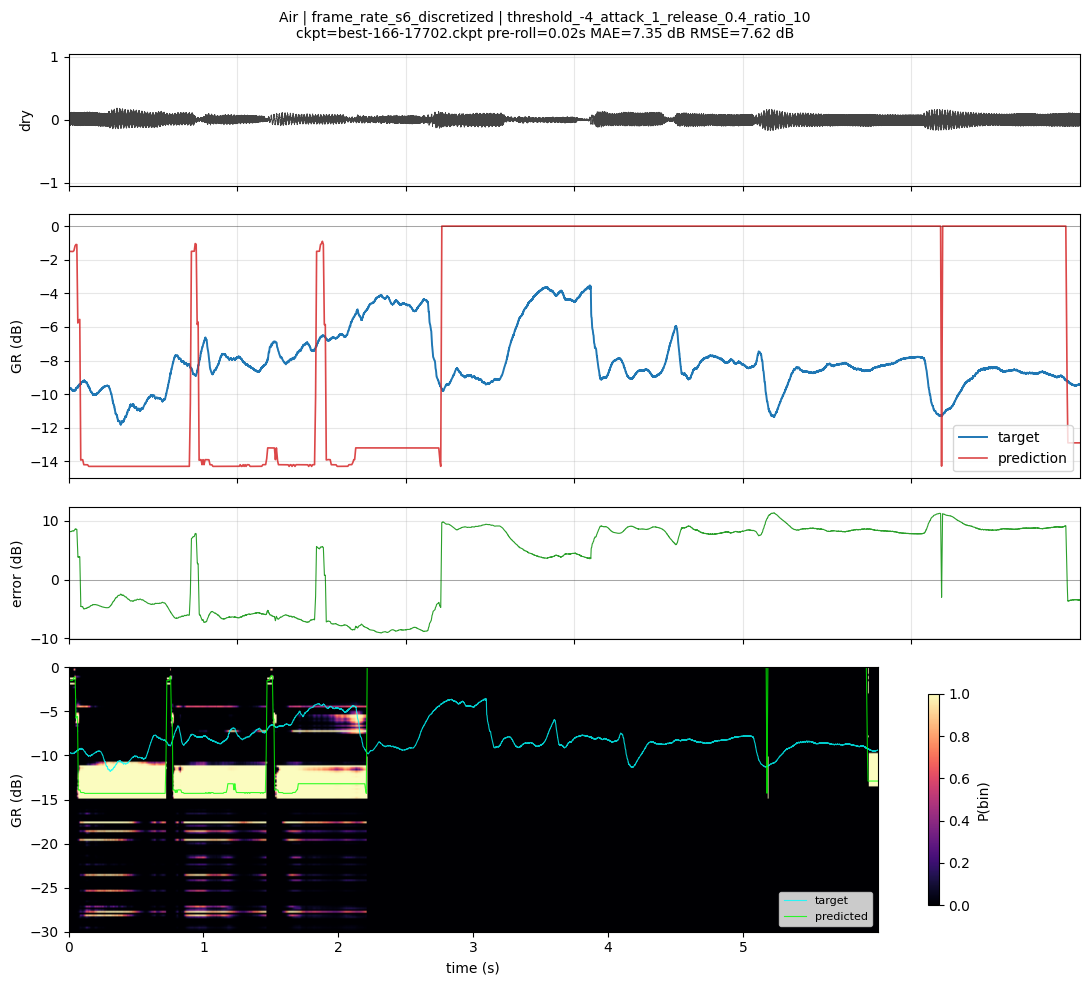

In [6]:
# 5. Single example

curves = visualize_prediction(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    hparams_path=HPARAMS_PATH,
    show_heatmap=True,
)

Comparing 3 of 10 pairs


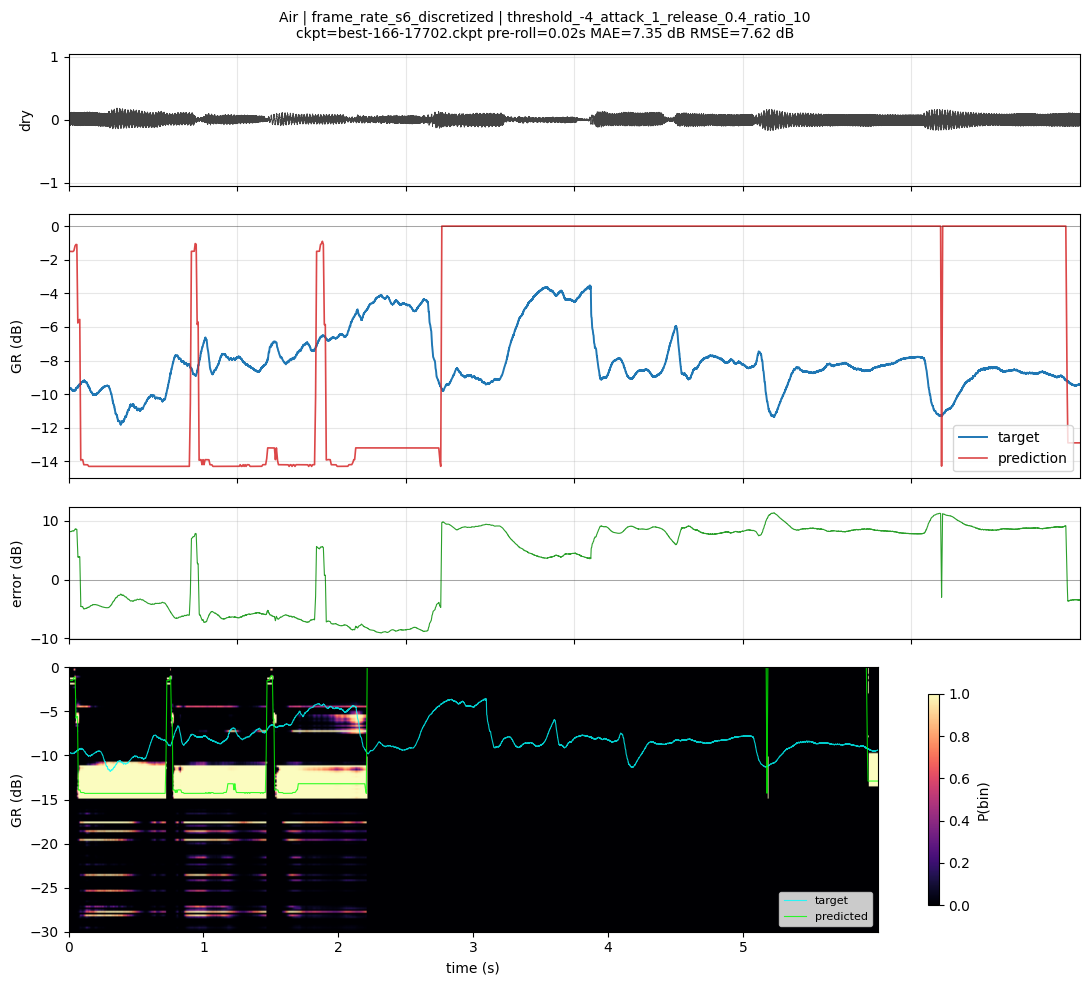

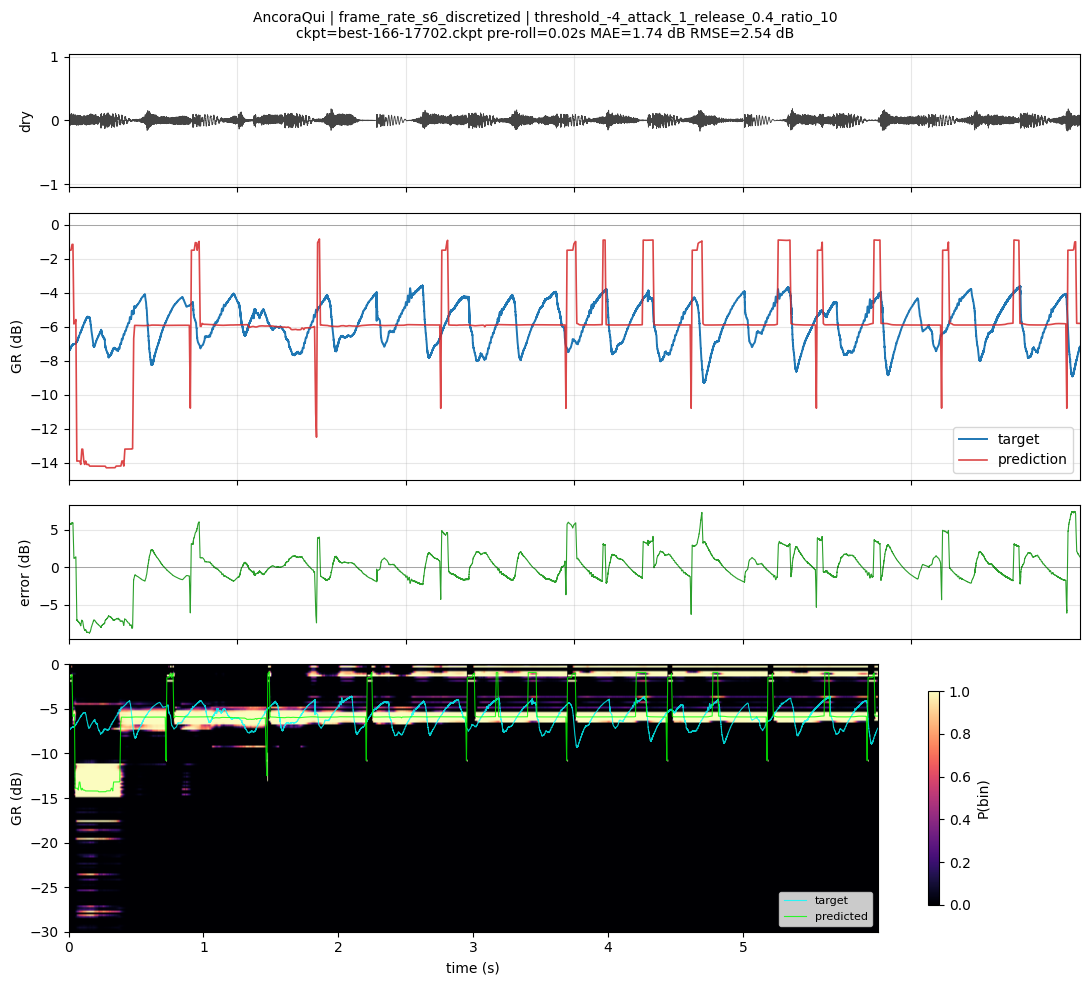

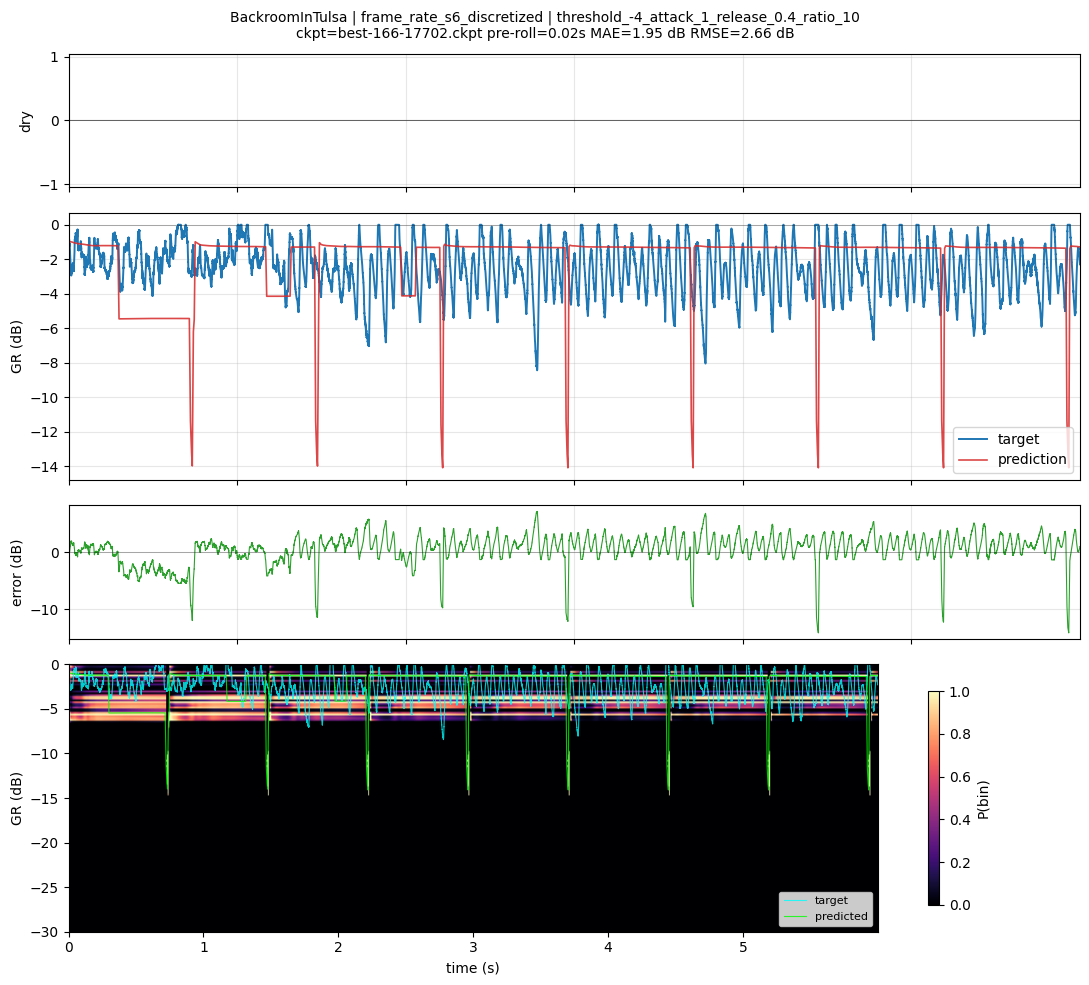

In [7]:
# 6. Compare across multiple songs

results = compare_same_setting_curves(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    max_pairs=3,
    start_pair=0,
    hparams_path=HPARAMS_PATH,
    show_heatmap=True,
)

In [8]:
# 7. Optional validation-set reconstructed-audio metrics
#
# Reconstructs the song-level validation split used during training, predicts GR
# in chunks, reconstructs wet audio as dry * 10 ** (GR_dB / 20), computes audio
# metrics per chunk, then reports one duration-weighted validation row.

from src.losses import compute_all_losses as compute_audio_losses


def _db_to_amplitude(db):
    return torch.pow(10.0, db / 20.0)


@torch.no_grad()
def _predict_segment_gr(system, dry_context, context_offset, target_len, device):
    if hasattr(system.model, "reset_states"):
        system.model.reset_states()

    x = dry_context.unsqueeze(0).to(device)
    with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
        logits = system(x)
        gr_context_db = system.model.to_db(logits, samples=dry_context.shape[-1])
        gr_context_db = gr_context_db.clamp(GR_DB_MIN, GR_DB_MAX)

    start = context_offset
    stop = context_offset + target_len
    return gr_context_db.squeeze(0)[..., start:stop].float().cpu()


def _pair_num_frames(dry_path, wet_path, sr):
    dry_info = sf.info(dry_path)
    wet_info = sf.info(wet_path)
    if dry_info.samplerate != sr or wet_info.samplerate != sr:
        print(
            f"[warning] {Path(dry_path).stem}: expected {sr} Hz, "
            f"got dry={dry_info.samplerate}, wet={wet_info.samplerate}; "
            "segment offsets assume matching sample rates."
        )
    return min(dry_info.frames, wet_info.frames)


def _song_from_dry_path(dry_path):
    return Path(dry_path).name.replace("_UnmasteredWAV.wav", "")


def _validation_pairs_from_training_split(all_pairs, hp):
    songs = sorted({_song_from_dry_path(dry_path) for dry_path, _ in all_pairs})
    split_seed = int(hp.get("split_seed", 42))
    train_split = float(hp.get("train_split", 0.8))

    generator = torch.Generator().manual_seed(split_seed)
    perm = torch.randperm(len(songs), generator=generator).tolist()
    n_train = int(len(songs) * train_split)
    n_train = min(max(1, n_train), len(songs) - 1)

    train_songs = {songs[i] for i in perm[:n_train]}
    val_songs = set(songs) - train_songs

    print(
        f"Validation split: {len(val_songs)} validation songs, "
        f"{len(train_songs)} train songs (seed={split_seed}, train_split={train_split})"
    )
    print(f"Validation songs: {sorted(val_songs)}")

    return [
        (dry_path, wet_path)
        for dry_path, wet_path in all_pairs
        if _song_from_dry_path(dry_path) in val_songs
    ]


from eval_helpers import (
    _db_to_amplitude,
    _pair_num_frames,
    _song_from_dry_path,
    _validation_pairs_from_training_split,
    _weighted_average_metric_rows,
)


# Leave as None to evaluate the full validation split. Use a small integer for a quick smoke test.
MAX_VALIDATION_SONGS: int | None = None
EVAL_VALIDATION_SONGS: list[str] | None = None

WHOLE_SONG_CHUNK_SEC = 10.0
WHOLE_SONG_PRE_ROLL_SEC = None
SAVE_CHUNK_METRICS = False

system, hp = load_system_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"])
device = torch.device(DEVICE)
chunk_frames = int(round(WHOLE_SONG_CHUNK_SEC * sr))
rf_samples = int(hp.get("s6", {}).get("hop_size", 256)) * 4
pre_roll_frames = rf_samples if WHOLE_SONG_PRE_ROLL_SEC is None else int(round(WHOLE_SONG_PRE_ROLL_SEC * sr))
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

all_pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)

if EVAL_VALIDATION_SONGS is not None:
    selected_names = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [
        (dry_path, wet_path)
        for dry_path, wet_path in eval_pairs
        if _song_from_dry_path(dry_path) in selected_names
    ]

if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]

assert eval_pairs, "No validation pairs selected for evaluation."

validation_chunk_rows = []
for song_idx, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    total_frames = _pair_num_frames(dry_path, wet_path, sr)
    print(
        f"[{song_idx}/{len(eval_pairs)}] Evaluating validation song {song} "
        f"({total_frames / sr:.1f}s, chunks of {WHOLE_SONG_CHUNK_SEC:.1f}s)"
    )

    for chunk_idx, start in enumerate(range(0, total_frames, chunk_frames), start=1):
        stop = min(start + chunk_frames, total_frames)
        context_start = max(0, start - pre_roll_frames)
        context_offset = start - context_start

        dry_context, wet_context = _read_dry_wet_segment(
            dry_path,
            wet_path,
            context_start,
            stop,
            sr,
        )
        target_len = min(
            stop - start,
            dry_context.shape[-1] - context_offset,
            wet_context.shape[-1] - context_offset,
        )
        if target_len <= 0:
            continue

        dry_chunk = dry_context[..., context_offset : context_offset + target_len]
        wet_chunk = wet_context[..., context_offset : context_offset + target_len]
        gr_pred_db = _predict_segment_gr(
            system,
            dry_context,
            context_offset,
            target_len,
            device,
        )
        pred_wet = dry_chunk * _db_to_amplitude(gr_pred_db)

        losses = compute_audio_losses(pred_wet.unsqueeze(0), wet_chunk.unsqueeze(0))
        validation_chunk_rows.append({
            "Song": song,
            "Chunk": chunk_idx,
            "Start (s)": start / sr,
            "Duration (s)": target_len / sr,
            "Frames": target_len,
            **losses,
        })

        del dry_context, wet_context, dry_chunk, wet_chunk, gr_pred_db, pred_wet
        if device.type == "cuda":
            torch.cuda.empty_cache()

    gc.collect()

assert validation_chunk_rows, "No validation chunks were evaluated."

weighted_metrics = _weighted_average_metric_rows(validation_chunk_rows, metric_cols)
total_frames = sum(row["Frames"] for row in validation_chunk_rows)
validation_metrics_df = pd.DataFrame([
    {
        "Split": "validation",
        "Songs": len(eval_pairs),
        "Chunks": len(validation_chunk_rows),
        "Duration (s)": total_frames / sr,
        **weighted_metrics,
    }
])

validation_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation_s6.csv"
validation_metrics_df.to_csv(validation_metrics_path, index=False)
print(f"Saved validation audio metrics -> {validation_metrics_path}")

if SAVE_CHUNK_METRICS:
    chunk_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation_chunks_s6.csv"
    pd.DataFrame(validation_chunk_rows).to_csv(chunk_metrics_path, index=False)
    print(f"Saved validation chunk audio metrics -> {chunk_metrics_path}")

display(validation_metrics_df)

Validation split: 2 validation songs, 8 train songs (seed=42, train_split=0.8)
Validation songs: ['Borderline', 'NosPalpitants']
[1/2] Evaluating validation song Borderline (273.9s, chunks of 10.0s)
[2/2] Evaluating validation song NosPalpitants (198.1s, chunks of 10.0s)
Saved validation audio metrics -> /Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs/s6_gr_20260525_181724_s6_v1_discretized_fixed_v3/eval_audio_metrics_validation_s6.csv


,Split,Songs,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,2,48,471.969365,0.016963,0.000793,3.046097,1.316387,0.960985,1.526802,1.356502
